# Semana 3 – Modelo de Comunicación Digital

**OBJETIVO DIDÁCTICO DEL NOTEBOOK**

Este notebook guía tiene como propósito ayudarte a **comprender el modelo de comunicación digital** mediante un experimento práctico y visual, utilizando un canal resonante como analogía del comportamiento de un receptor selectivo. Analizaremos cómo una señal compleja pasa por un canal que solo permite ciertas frecuencias, ayudando a interpretar cómo funcionan etapas del sistema como la **modulación, canal y demodulación**.

---

## Glosario de términos clave

- **Modelo de comunicación digital**: representación funcional de un sistema que transmite información digital de un emisor a un receptor, incluyendo procesos como codificación, modulación, transmisión y recepción.
- **Sweep de frecuencias**: señal en la que la frecuencia varía de forma continua dentro de un rango definido. Se utiliza para explorar la respuesta del canal a diferentes frecuencias.
- **Canal resonante**: sistema que permite pasar solo una banda estrecha de frecuencias alrededor de una frecuencia central.
- **Ancho de banda (Bandwidth)**: intervalo de frecuencias que un sistema puede transmitir o recibir eficazmente.
- **Frecuencia central**: frecuencia a la cual un filtro o canal tiene su máxima respuesta.

---


## 1. Generación y caracterización de una señal tipo sweep

Vamos a generar una señal que represente un **barrido de frecuencias** (sweep), donde la frecuencia aumenta linealmente de 100 Hz a 2000 Hz en 2 segundos.

Esto simula una señal enviada por el **emisor**, quien transmite una mezcla de muchas frecuencias.

---

### ¿Qué esperar de esta señal?

La forma de onda cambiará de lenta a rápida:  
- Al inicio (100 Hz), veremos **pocas oscilaciones por segundo**.
- Al final (2000 Hz), veremos **muchas oscilaciones por segundo**.

Es decir, **la densidad de las ondas aumenta con el tiempo**, y lo podemos visualizar si observamos con cuidado en distintos intervalos.


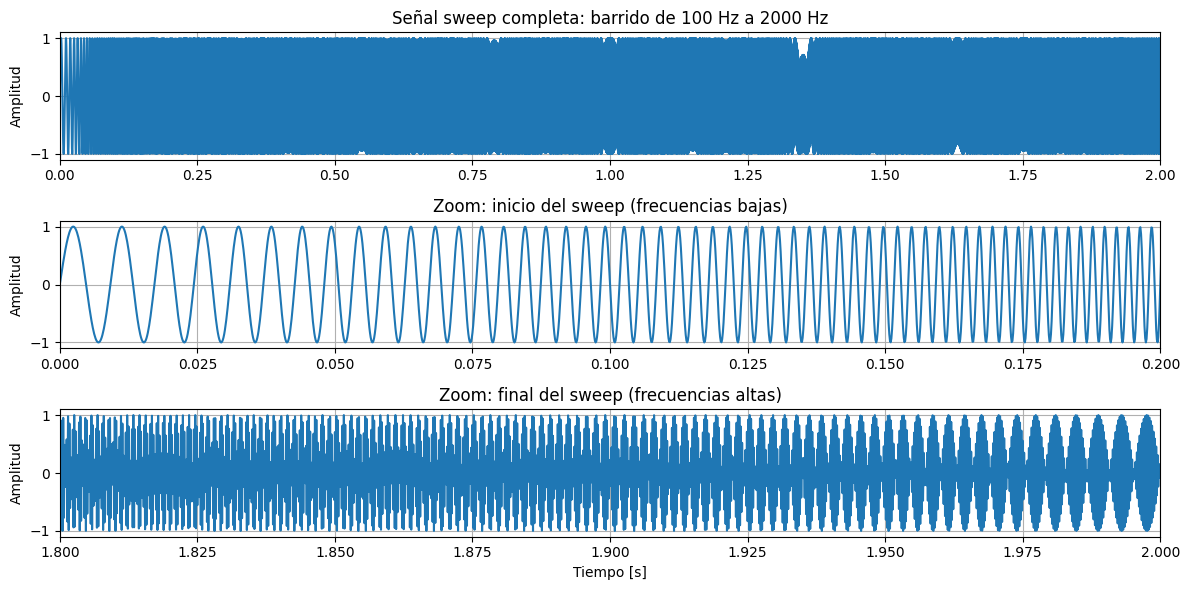

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 8000  # Frecuencia de muestreo
T = 2.0    # Duración en segundos
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Sweep: frecuencia aumenta de 100 Hz a 2000 Hz
f0, f1 = 100, 2000
sweep = np.sin(2 * np.pi * (f0 + (f1 - f0) * t / T) * t)

fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharey=True)

axs[0].plot(t, sweep)
axs[0].set_xlim(0, 2)
axs[0].set_title("Señal sweep completa: barrido de 100 Hz a 2000 Hz")

axs[1].plot(t, sweep)
axs[1].set_xlim(0, 0.2)
axs[1].set_title("Zoom: inicio del sweep (frecuencias bajas)")

axs[2].plot(t, sweep)
axs[2].set_xlim(1.8, 2)
axs[2].set_title("Zoom: final del sweep (frecuencias altas)")

for ax in axs:
    ax.set_ylabel("Amplitud")
    ax.grid(True)

axs[2].set_xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

## 2. Análisis espectral del sweep (¿qué frecuencias contiene?)

Vamos a analizar **qué frecuencias contiene la señal sweep** utilizando la Transformada Rápida de Fourier (FFT). Esto nos da su **contenido espectral**, como si tomáramos una linterna y la usáramos para ver el “ADN de frecuencias” de la señal.

---

###  ¿Qué hace la FFT? – Analogía tipo Feynman

Imagina que tienes una canción que alguien está tocando en un piano, pero tú no puedes verla, solo escucharla. ¿Cómo sabrías qué teclas están siendo presionadas en cada momento?

La **Transformada de Fourier** es como tener una cámara especial que te muestra **qué teclas (frecuencias)** están siendo tocadas y **con qué fuerza (amplitud)**. No importa que estén todas sonando a la vez: esta herramienta las separa mágicamente.

---

Dado que nuestro sweep contiene todas las frecuencias entre 100 Hz y 2000 Hz, esperamos que el gráfico muestre una **línea plana** entre esas frecuencias. Eso confirmaría que **todas estuvieron presentes en igual proporción**.

Vamos a comprobarlo:


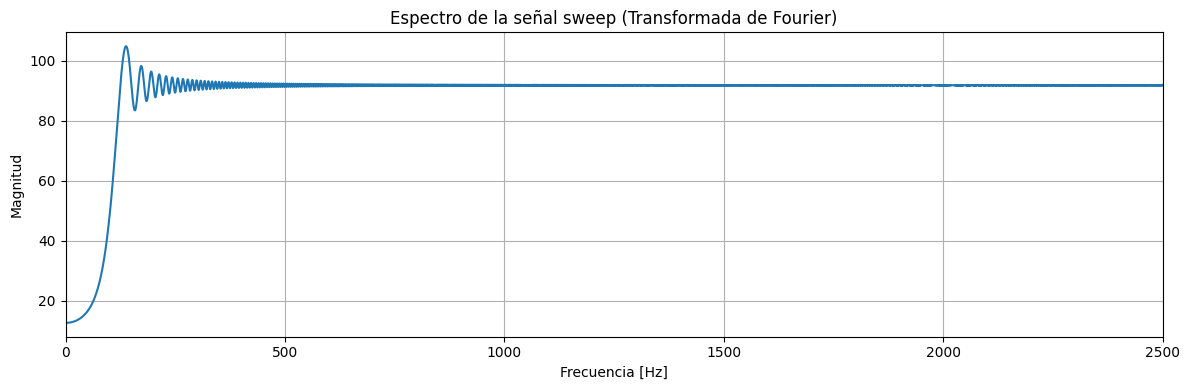

In [4]:
from scipy.fft import fft, fftfreq

N = len(sweep)
frecuencias = fftfreq(N, 1/fs)
espectro = np.abs(fft(sweep))

plt.figure(figsize=(12, 4))
plt.plot(frecuencias[:N//2], espectro[:N//2])
plt.title("Espectro de la señal sweep (Transformada de Fourier)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 2500)  # Enfocamos en el rango esperado
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Canal resonante (analogía del receptor)

Un **canal resonante** deja pasar únicamente las frecuencias cercanas a una frecuencia central. Esto se puede lograr con un **filtro pasa banda**.

En este caso, el canal simula un receptor sintonizado a 880 Hz con un **ancho de banda** de 50 Hz (solo deja pasar señales entre 855 y 905 Hz).


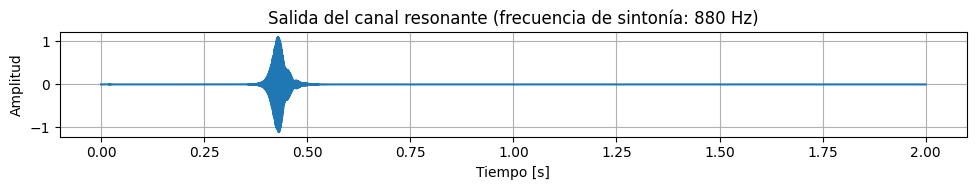

In [5]:
from scipy.signal import butter, lfilter

def canal_resonante(senal, fs, freq_central, ancho):
    nyq = fs / 2
    low = (freq_central - ancho/2) / nyq
    high = (freq_central + ancho/2) / nyq
    b, a = butter(4, [low, high], btype='band')
    return lfilter(b, a, senal)

resonancia = 880  # Hz
bw = 50           # Ancho de banda
salida_canal = canal_resonante(sweep, fs, resonancia, bw)

plt.figure(figsize=(10, 2))
plt.plot(t, salida_canal)
plt.title("Salida del canal resonante (frecuencia de sintonía: 880 Hz)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.tight_layout()
plt.show()

## 5. ¿Qué quedó después del canal? (frecuencia filtrada)

 Ahora analizamos qué frecuencia pasó a través del canal.

Solo la frecuencia resonante debe conservarse.


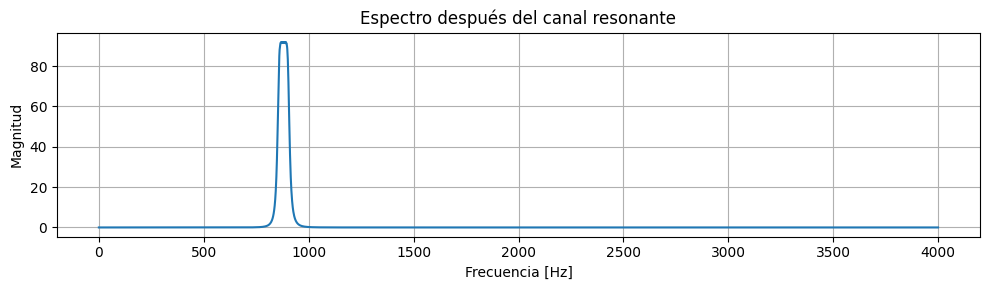

In [6]:
N = len(salida_canal)
frecuencias = fftfreq(N, 1/fs)
espectro_filtrado = np.abs(fft(salida_canal))

plt.figure(figsize=(10, 3))
plt.plot(frecuencias[:N//2], espectro_filtrado[:N//2])
plt.title("Espectro después del canal resonante")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid()
plt.tight_layout()
plt.show()

## 6. Reflexión guiada

 Reflexiona con base en lo que viste:

1. ¿Qué parte del modelo representa el sweep? ¿Y el canal?
2. ¿Por qué el canal dejó pasar solo una parte de la señal?
3. ¿Qué pasaría si el ancho de banda fuera mayor? ¿Y si fuera menor?
4. ¿Cómo se relaciona esto con la recepción selectiva de señales digitales?

 Anota tus respuestas y tenlas listas para resolver el archivo `semana3_modelo_comunicacion.py`.
